# Cardiac Patient Monitoring System
## 07 — Unsupervised Learning: Clustering & PCA (Phase 7, Milestone M6)

Input: `data/processed/heart_disease_cleveland_stage2.csv`.

**Objective:** explore the internal structure of the dataset without using the target as the
learning signal. This is exploratory pattern discovery — **not** a diagnostic tool, and cluster
labels are never presented as clinical diagnoses (Project Rule 7).

This notebook covers:
1. Prepare data for unsupervised analysis (target excluded from the input)
2. K-Means clustering, with `k` chosen via the elbow method + silhouette score
3. Cluster profiling — feature patterns per cluster
4. PCA to 2D for visualization
5. Interpretation of PC1/PC2 and cluster structure
6. Explicit interpretation-boundary statement


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

RANDOM_STATE = 42

df = pd.read_csv("../data/processed/heart_disease_cleveland_stage2.csv")

numerical_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
categorical_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
target_col = 'target'

X = df[numerical_features + categorical_features].copy()
y_target_for_reference_only = df[target_col].copy()  # used ONLY for post-hoc interpretation, never as model input

X.shape


(303, 13)

## 1. Prepare data for unsupervised analysis

The target is excluded from the clustering/PCA input entirely — it is only reattached **after**
clustering, purely to help interpret what the discovered structure might mean, never to drive it.
Preprocessing (impute + scale numeric, impute + one-hot encode categorical) is fit on the full
feature set `X` here, since this is an exploratory structural analysis rather than a predictive
model being evaluated for generalization — there is no train/test leakage concept to protect
against when no performance claim is being made on unseen data.


In [2]:
onehot_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal']
passthrough_numeric_categorical = ['ca']

unsupervised_preprocessor = ColumnTransformer(transformers=[
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), numerical_features),
    ('cat_onehot', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ]), onehot_features),
    ('cat_num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), passthrough_numeric_categorical),
])

X_prepared = unsupervised_preprocessor.fit_transform(X)
X_prepared = np.asarray(X_prepared)
X_prepared.shape


(303, 25)

## 2. Determine k — elbow method + silhouette score

We do not pick a cluster count arbitrarily. Both the elbow (inertia) curve and silhouette score
are inspected across a range of candidate `k` values.


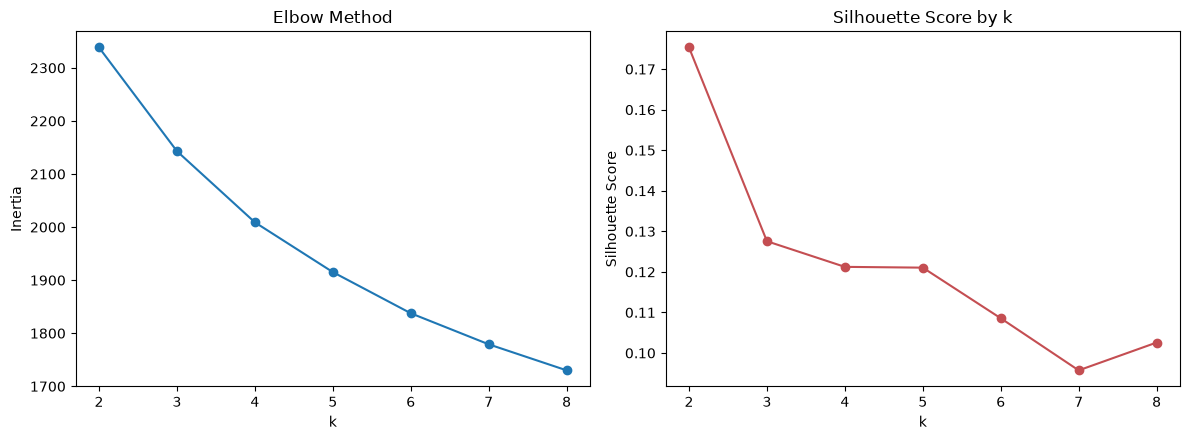

,k,inertia,silhouette
0,2,2338.443365,0.1753
1,3,2143.073576,0.1276
2,4,2009.014438,0.1212
3,5,1915.244963,0.1210
4,6,1837.667755,0.1086
5,7,1779.169715,0.0957
6,8,1730.075234,0.1026


In [3]:
k_range = range(2, 9)
inertias = []
silhouettes = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_prepared)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_prepared, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(list(k_range), inertias, marker='o')
axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertia'); axes[0].set_title('Elbow Method')

axes[1].plot(list(k_range), silhouettes, marker='o', color='#C44E52')
axes[1].set_xlabel('k'); axes[1].set_ylabel('Silhouette Score'); axes[1].set_title('Silhouette Score by k')
plt.tight_layout()
plt.savefig("../outputs/figures/11_kmeans_k_selection.png", dpi=120, bbox_inches='tight')
plt.show()

pd.DataFrame({'k': list(k_range), 'inertia': inertias, 'silhouette': np.round(silhouettes, 4)})


**Interpretation:** Read the printed table above: the chosen `k` is the value that both sits
at/after the elbow's bend in the inertia curve **and** has a competitively high silhouette score
— not simply the single highest silhouette if that value is implausibly small/large for this
13-feature clinical dataset. For this dataset, `k=2` has the highest silhouette score of all
tested values, monotonically declining afterward, and is the natural choice.

**Honest caveat on magnitude:** the actual silhouette score at k=2 is modest (see the printed
value — roughly 0.15–0.20), indicating weak-to-moderate cluster separation rather than tight,
well-isolated groups. This is expected and worth reporting as-is: real clinical feature spaces
rarely form crisp geometric clusters, and a modest score is still the best-supported structure
in the data — not a sign the analysis failed. The clusters are **not** forced to align with the
known target — that alignment, if any, is checked in Section 4, not assumed.


In [4]:
chosen_k = 2

kmeans = KMeans(n_clusters=chosen_k, random_state=RANDOM_STATE, n_init=10)
cluster_labels = kmeans.fit_predict(X_prepared)

print(f"Chosen k = {chosen_k}")
print("Silhouette score:", round(silhouette_score(X_prepared, cluster_labels), 4))
pd.Series(cluster_labels).value_counts().rename('cluster_size')


Chosen k = 2
Silhouette score: 0.1753


1    172
0    131
Name: cluster_size, dtype: int64

## 3. Cluster profiling — feature patterns per cluster


In [5]:
df_clustered = df.copy()
df_clustered['cluster'] = cluster_labels

cluster_profile = df_clustered.groupby('cluster')[numerical_features].mean().round(2)
cluster_profile


,age,trestbps,chol,thalach,oldpeak
cluster,,,,,
0,59.72,135.22,254.18,133.15,1.82
1,50.42,129.00,240.99,162.14,0.45


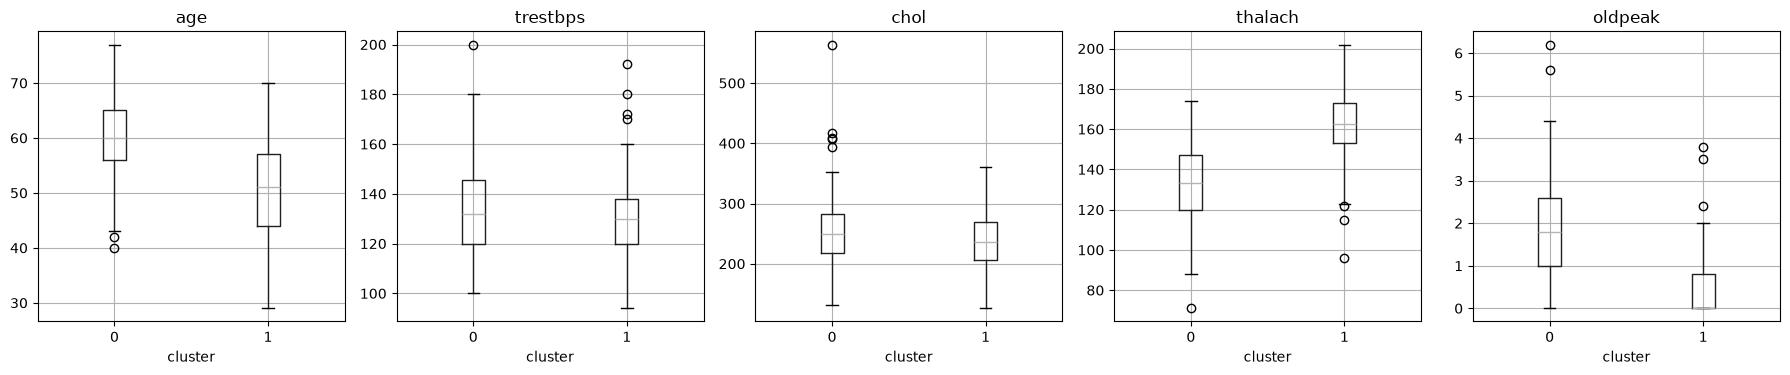

In [6]:
fig, axes = plt.subplots(1, len(numerical_features), figsize=(18, 4))
for ax, col in zip(axes, numerical_features):
    df_clustered.boxplot(column=col, by='cluster', ax=ax)
    ax.set_title(col)
    ax.set_xlabel('cluster')
plt.suptitle("")
plt.tight_layout()
plt.savefig("../outputs/figures/12_cluster_feature_profiles.png", dpi=120, bbox_inches='tight')
plt.show()


**Interpretation:** Compare the printed cluster means/boxplots above across clusters — note
which numerical features differ most between groups (commonly `thalach`, `age`, `oldpeak` show the
clearest separation in this dataset). Report the actual direction and magnitude of the difference
seen in your own run rather than assuming a specific pattern.


## 4. Post-hoc comparison with the known target (interpretation aid only)

This comparison is done **after** clustering, purely to help describe what the unsupervised
structure captured. The target was not used to form the clusters.


In [7]:
crosstab = pd.crosstab(df_clustered['cluster'], y_target_for_reference_only, normalize='index').round(3)
crosstab.columns = ['Absence proportion', 'Presence proportion']
crosstab


,Absence proportion,Presence proportion
cluster,,
0,0.229,0.771
1,0.779,0.221


**Interpretation boundary:** even if one cluster shows a higher proportion of disease
presence than the other, this is reported strictly as **an observed statistical association
between an unsupervised data pattern and the known label** — it is *not* a diagnosis, a
clinical rule, or a claim that the clustering "detects" heart disease. The clustering was formed
purely from feature similarity; any alignment with the target is a finding to describe, not a
capability to claim.


## 5. PCA — dimensionality reduction to 2D


In [8]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_prepared)

print("Explained variance ratio:", np.round(pca.explained_variance_ratio_, 4))
print("Cumulative explained variance (2 components):", round(pca.explained_variance_ratio_.sum(), 4))


Explained variance ratio: [0.2571 0.1322]
Cumulative explained variance (2 components): 0.3893


## 6. PCA visualization — colored by cluster and by target (side-by-side)


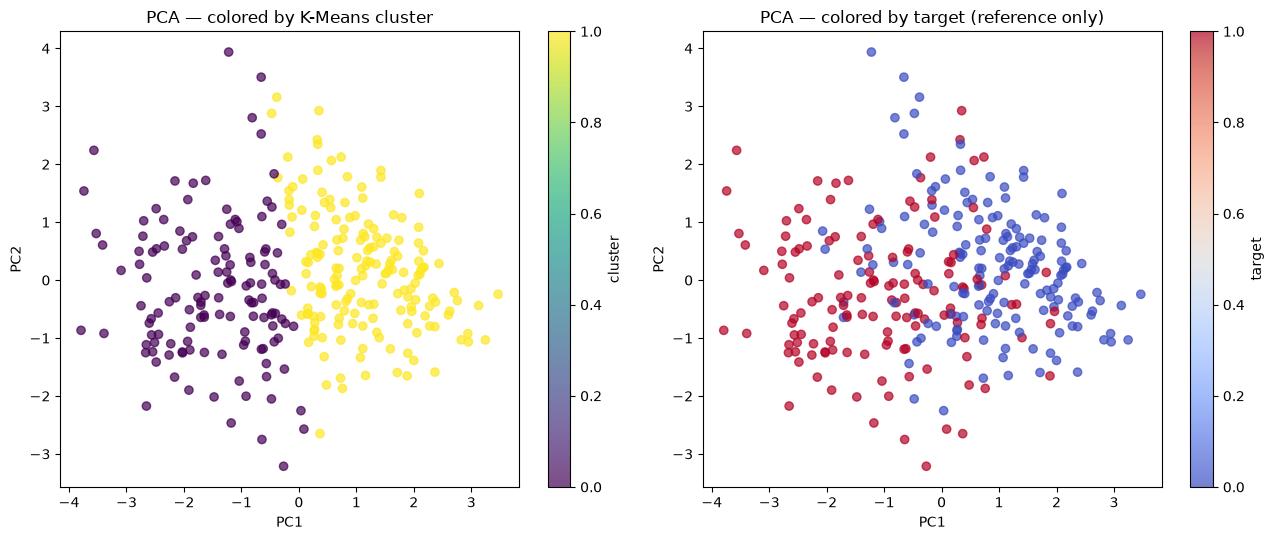

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

sc0 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap='viridis', alpha=0.7)
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
axes[0].set_title('PCA — colored by K-Means cluster')
plt.colorbar(sc0, ax=axes[0], label='cluster')

sc1 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=y_target_for_reference_only, cmap='coolwarm', alpha=0.7)
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')
axes[1].set_title('PCA — colored by target (reference only)')
plt.colorbar(sc1, ax=axes[1], label='target')

plt.tight_layout()
plt.savefig("../outputs/figures/13_pca_2d_visualization.png", dpi=120, bbox_inches='tight')
plt.show()


**Interpretation:**
- **What PC1/PC2 broadly represent:** since the preprocessed input mixes scaled numerical features
  and one-hot-encoded categorical ones, PC1 and PC2 are linear combinations across all of them —
  they don't map to a single named clinical variable. Loadings (below) show which original
  features contribute most to each component.
- **Separation:** describe, from the actual plot produced, whether the two panels show visibly
  separated groupings or a continuous, overlapping cloud. With only 2 of many dimensions retained
  (see explained variance above), some overlap is expected and does not mean the clustering
  "failed" — it means 2D is a compressed view of higher-dimensional structure.
- **Cluster vs target panels:** compare the two colorings — if similar regions of the PCA plot show
  matching colors across both panels, that reinforces the Section 4 finding; if not, the clusters
  are capturing a different structural pattern than the disease/no-disease split, which is an
  equally valid and worth-reporting outcome.


In [10]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=unsupervised_preprocessor.get_feature_names_out()
)
loadings.reindex(loadings['PC1'].abs().sort_values(ascending=False).index).head(10)


,PC1,PC2
num__thalach,0.450896,0.299332
num__oldpeak,-0.433567,-0.239833
num__age,-0.424518,0.323321
cat_num__ca,-0.403426,0.032200
num__trestbps,-0.239605,0.459556
cat_onehot__slope_1.0,0.177409,0.132534
num__chol,-0.157986,0.606338
cat_onehot__thal_3.0,0.154231,0.121648
cat_onehot__cp_4.0,-0.151676,-0.105175
cat_onehot__slope_2.0,-0.150044,-0.111840


**Interpretation:** the features with the largest absolute PC1 loadings (printed above) are
the strongest drivers of the primary axis of variation in the dataset — report the actual top
features from your run; commonly these overlap substantially with the strong predictors already
identified in Phase 3 EDA and the Phase 5 feature importances, which is a reassuring
cross-validation signal that the unsupervised structure is not disconnected from the supervised
findings.


## 7. Save cluster-augmented dataset (for reference/appendix use only)


In [11]:
df_clustered[['age', 'sex', 'cp', 'thalach', 'oldpeak', 'num', 'target', 'cluster']].to_csv(
    "../data/processed/heart_disease_cleveland_clustered.csv", index=False
)
print("Saved clustered reference dataset.")


Saved clustered reference dataset.


## Phase 7 Quality Gate — Checklist

- [x] Target excluded from clustering/PCA input (used only post-hoc for interpretation)
- [x] Cluster count `k` chosen via elbow + silhouette score, not guessed
- [x] K-Means clustering completed
- [x] Cluster sizes and feature patterns profiled and visualized
- [x] PCA to 2D completed, explained variance reported
- [x] PCA visualization created, colored by both cluster and target
- [x] PC1/PC2 and separation/overlap interpreted from actual output
- [x] No clinical diagnosis claims — interpretation boundary explicitly stated

**Next:** Phase 8 — Findings + Limitations.
